In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prediction_results = pd.read_csv(
    "../data/processed/next_month_demand_predictions.csv"
)

print("Shape:", prediction_results.shape)
prediction_results.head()

Shape: (10083, 6)


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error,Demand_Level
0,10080,2011-07,60.0,83.393261,23.393261,51-100
1,10080,2011-08,60.0,79.975290,19.975290,51-100
2,10080,2011-09,6.0,91.587638,85.587638,0-10
3,10080,2011-10,91.0,72.072986,18.927014,51-100
4,10120,2011-08,10.0,61.733462,51.733462,0-10


In [4]:
prediction_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10083 entries, 0 to 10082
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   StockCode            10083 non-null  object 
 1   MonthYear            10083 non-null  object 
 2   Next_Month_Quantity  10083 non-null  float64
 3   Predicted_Quantity   10083 non-null  float64
 4   Absolute_Error       10083 non-null  float64
 5   Demand_Level         10083 non-null  object 
dtypes: float64(3), object(3)
memory usage: 472.8+ KB


In [5]:
prediction_results.describe()

,Next_Month_Quantity,Predicted_Quantity,Absolute_Error
count,10083.000000,10083.000000,10083.000000
mean,189.539919,194.614906,108.564885
std,438.770234,363.338952,241.805371
min,0.000000,0.000000,0.016981
25%,12.000000,39.643726,19.854945
50%,49.000000,80.485913,40.670888
75%,179.000000,195.419009,98.409279
max,12452.000000,7758.953156,6369.953156


In [6]:
# Performance by demand level

demand_level_summary = (
    prediction_results
    .groupby("Demand_Level")
    .agg(
        Products=("StockCode", "count"),
        MAE=("Absolute_Error", "mean"),
        Actual_Demand=("Next_Month_Quantity", "mean"),
        Predicted_Demand=("Predicted_Quantity", "mean")
    )
    .reset_index()
)

demand_level_summary

,Demand_Level,Products,MAE,Actual_Demand,Predicted_Demand
0,0-10,2414,38.564970,3.854184,42.419154
1,1001-5000,345,720.870764,1700.205797,1251.763389
2,101-500,2638,117.237539,230.744503,244.463259
3,11-50,2701,46.245068,26.935579,71.904969
4,5000+,13,2868.175329,6525.153846,3803.599279
5,501-1000,645,316.108698,699.232558,591.293350
6,51-100,1327,58.407342,73.825923,119.143549


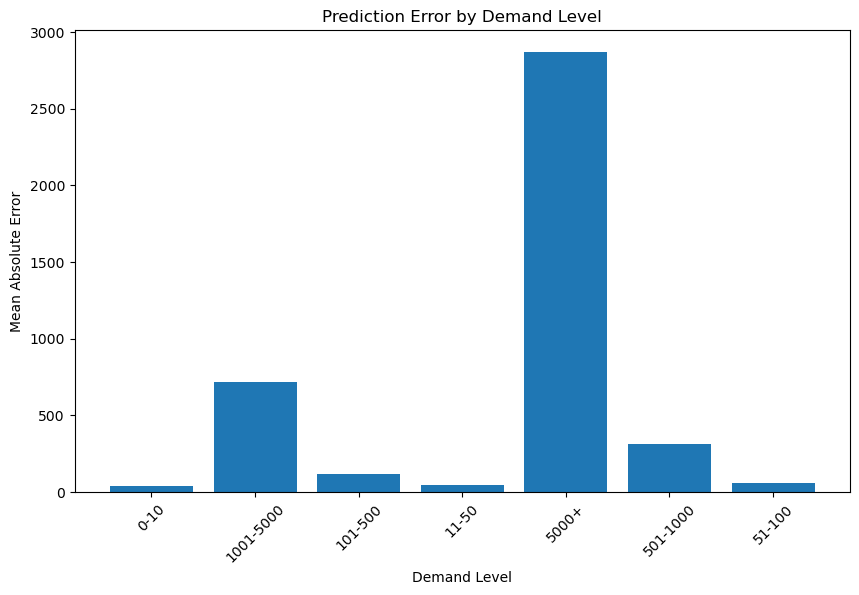

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    demand_level_summary["Demand_Level"],
    demand_level_summary["MAE"]
)

plt.xlabel("Demand Level")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Demand Level")
plt.xticks(rotation=45)

plt.show()

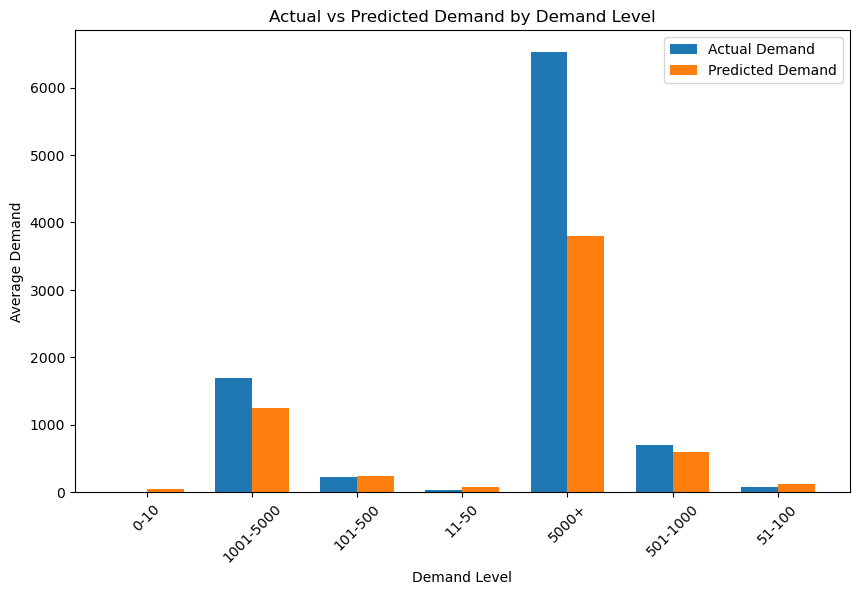

In [8]:
plt.figure(figsize=(10, 6))

x = np.arange(len(demand_level_summary))
width = 0.35

plt.bar(
    x - width/2,
    demand_level_summary["Actual_Demand"],
    width,
    label="Actual Demand"
)

plt.bar(
    x + width/2,
    demand_level_summary["Predicted_Demand"],
    width,
    label="Predicted Demand"
)

plt.xlabel("Demand Level")
plt.ylabel("Average Demand")
plt.title("Actual vs Predicted Demand by Demand Level")
plt.xticks(
    x,
    demand_level_summary["Demand_Level"],
    rotation=45
)
plt.legend()

plt.show()

In [9]:
# Set logical order for Demand Level

demand_order = [
    "0-10",
    "11-50",
    "51-100",
    "101-500",
    "501-1000",
    "1001-5000",
    "5000+"
]

prediction_results["Demand_Level"] = pd.Categorical(
    prediction_results["Demand_Level"],
    categories=demand_order,
    ordered=True
)

# Recalculate summary in correct order

demand_level_summary = (
    prediction_results
    .groupby("Demand_Level", observed=False)
    .agg(
        Products=("StockCode", "count"),
        MAE=("Absolute_Error", "mean"),
        Actual_Demand=("Next_Month_Quantity", "mean"),
        Predicted_Demand=("Predicted_Quantity", "mean")
    )
    .reset_index()
)

demand_level_summary

,Demand_Level,Products,MAE,Actual_Demand,Predicted_Demand
0,0-10,2414,38.564970,3.854184,42.419154
1,11-50,2701,46.245068,26.935579,71.904969
2,51-100,1327,58.407342,73.825923,119.143549
3,101-500,2638,117.237539,230.744503,244.463259
4,501-1000,645,316.108698,699.232558,591.293350
5,1001-5000,345,720.870764,1700.205797,1251.763389
6,5000+,13,2868.175329,6525.153846,3803.599279


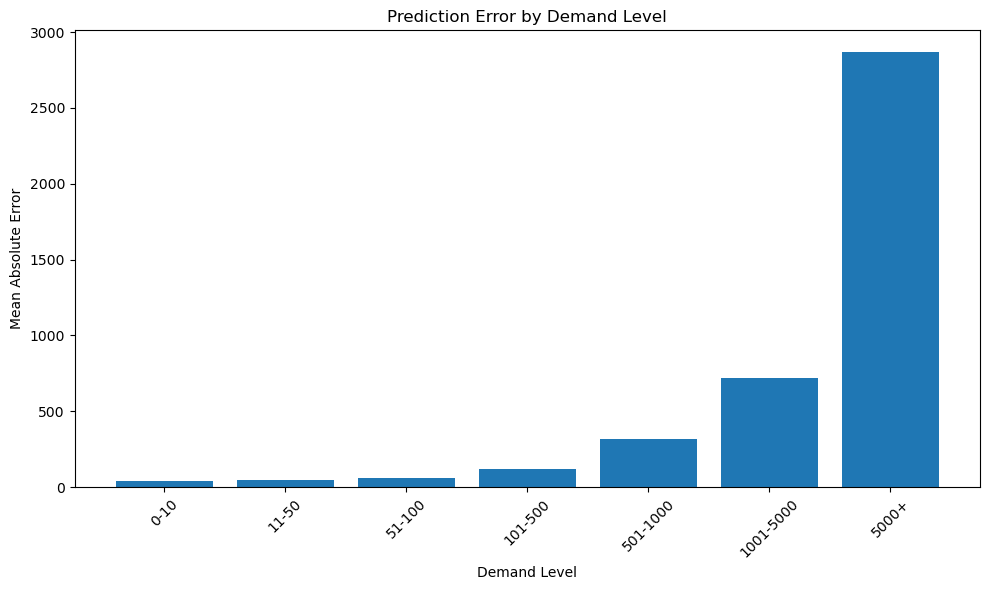

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    demand_level_summary["Demand_Level"],
    demand_level_summary["MAE"]
)

plt.xlabel("Demand Level")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Demand Level")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

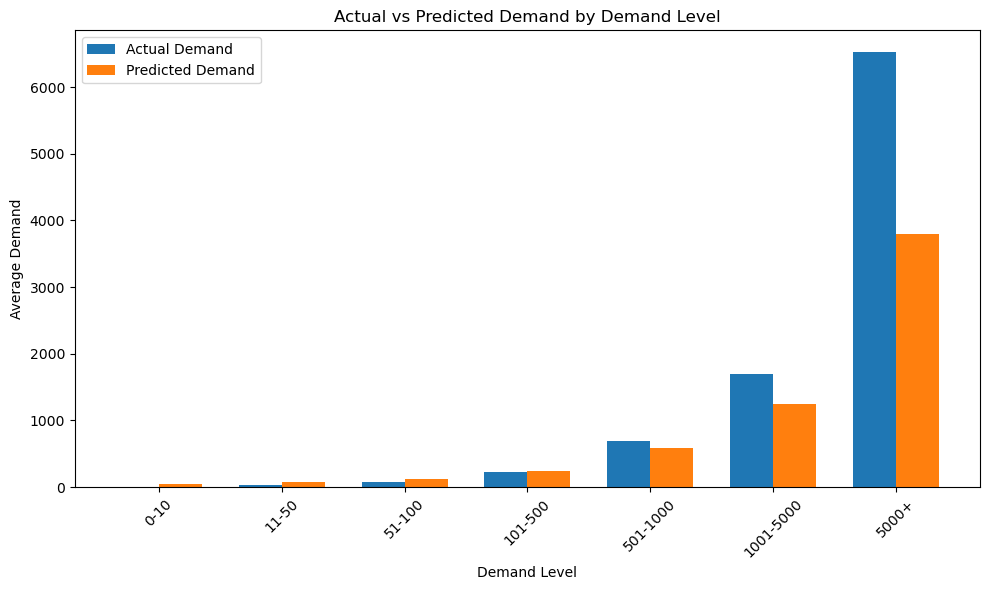

In [11]:
x = np.arange(len(demand_level_summary))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    demand_level_summary["Actual_Demand"],
    width,
    label="Actual Demand"
)

plt.bar(
    x + width/2,
    demand_level_summary["Predicted_Demand"],
    width,
    label="Predicted Demand"
)

plt.xlabel("Demand Level")
plt.ylabel("Average Demand")
plt.title("Actual vs Predicted Demand by Demand Level")

plt.xticks(
    x,
    demand_level_summary["Demand_Level"],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Select a product for demonstration

product_code = prediction_results["StockCode"].iloc[0]

product_data = prediction_results[
    prediction_results["StockCode"] == product_code
].copy()

print("Selected Product:", product_code)
print("Number of prediction records:", len(product_data))

product_data[
    [
        "StockCode",
        "MonthYear",
        "Next_Month_Quantity",
        "Predicted_Quantity",
        "Absolute_Error"
    ]
].head(20)

Selected Product: 10080
Number of prediction records: 4


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error
0,10080,2011-07,60.0,83.393261,23.393261
1,10080,2011-08,60.0,79.975290,19.975290
2,10080,2011-09,6.0,91.587638,85.587638
3,10080,2011-10,91.0,72.072986,18.927014


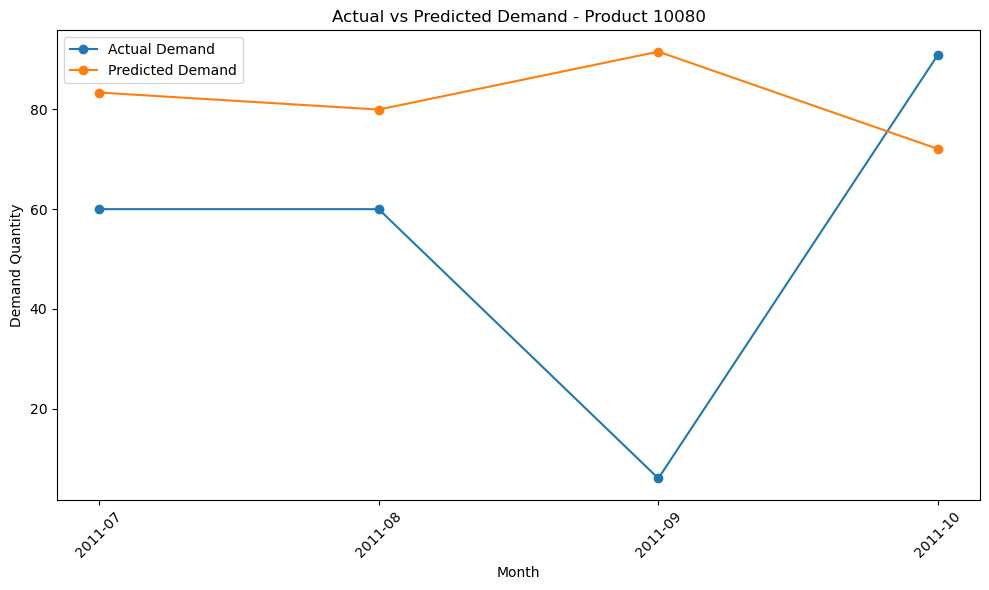

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    product_data["MonthYear"],
    product_data["Next_Month_Quantity"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    product_data["MonthYear"],
    product_data["Predicted_Quantity"],
    marker="o",
    label="Predicted Demand"
)

plt.xlabel("Month")
plt.ylabel("Demand Quantity")
plt.title(f"Actual vs Predicted Demand - Product {product_code}")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
product_mae = product_data["Absolute_Error"].mean()

product_rmse = np.sqrt(
    np.mean(
        (
            product_data["Next_Month_Quantity"]
            - product_data["Predicted_Quantity"]
        ) ** 2
    )
)

print("Product:", product_code)
print("Product MAE:", product_mae)
print("Product RMSE:", product_rmse)

Product: 10080
Product MAE: 36.9708008708996
Product RMSE: 46.448176953217796


In [15]:
# Show available products

available_products = sorted(
    prediction_results["StockCode"].unique()
)

print("Number of available products:", len(available_products))
print("\nFirst 30 products:")
print(available_products[:30])

Number of available products: 2549

First 30 products:
['10080', '10120', '10125', '10133', '10135', '11001', '15030', '15034', '15036', '15039', '15044A', '15044B', '15044C', '15044D', '15056BL', '15056N', '15056P', '15056bl', '15056n', '15056p', '15058A', '15058B', '15058C', '15060B', '15060b', '16008', '16011', '16012', '16014', '16016']


In [16]:
# Select a product manually

product_code = input("Enter StockCode: ").strip()

# Check whether the product exists
if product_code not in available_products:
    print("Product not found. Please enter a valid StockCode.")
else:
    product_data = prediction_results[
        prediction_results["StockCode"] == product_code
    ].copy()

    print("\nSelected Product:", product_code)
    print("Prediction records:", len(product_data))

    display(
        product_data[
            [
                "StockCode",
                "MonthYear",
                "Next_Month_Quantity",
                "Predicted_Quantity",
                "Absolute_Error"
            ]
        ]
    )

Enter StockCode:  10135



Selected Product: 10135
Prediction records: 5


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error
15,10135,2011-07,151.0,148.146815,2.853185
16,10135,2011-08,70.0,129.139337,59.139337
17,10135,2011-09,69.0,123.327330,54.327330
18,10135,2011-10,181.0,108.343618,72.656382
19,10135,2011-11,69.0,101.581751,32.581751


Product: 10135
Product MAE: 44.31
Product RMSE: 50.59


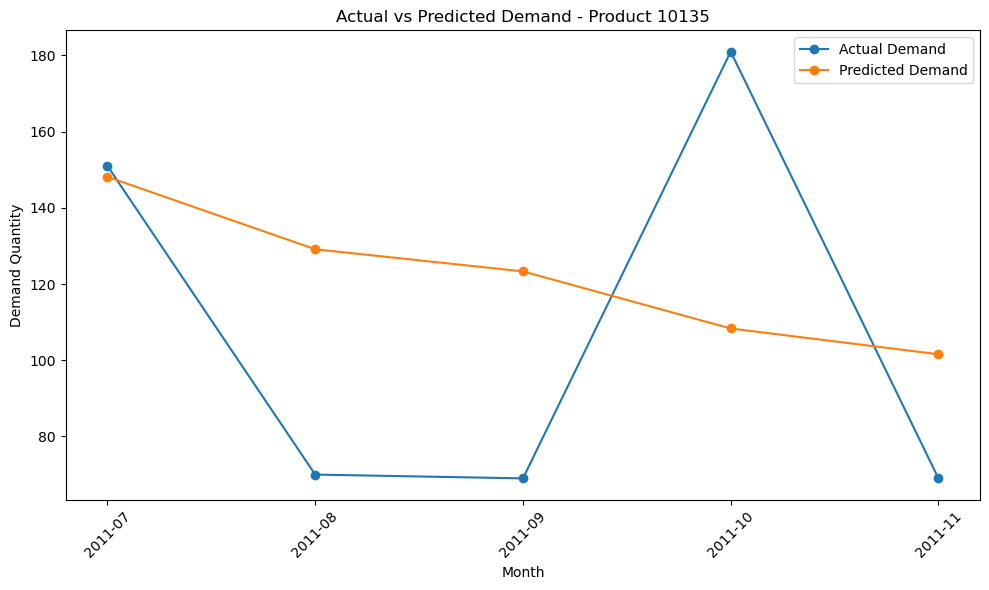

In [17]:
# Calculate performance for selected product

if product_code in available_products:

    product_mae = product_data["Absolute_Error"].mean()

    product_rmse = np.sqrt(
        np.mean(
            (
                product_data["Next_Month_Quantity"]
                - product_data["Predicted_Quantity"]
            ) ** 2
        )
    )

    print("Product:", product_code)
    print("Product MAE:", round(product_mae, 2))
    print("Product RMSE:", round(product_rmse, 2))

    # Plot actual vs predicted demand

    plt.figure(figsize=(10, 6))

    plt.plot(
        product_data["MonthYear"],
        product_data["Next_Month_Quantity"],
        marker="o",
        label="Actual Demand"
    )

    plt.plot(
        product_data["MonthYear"],
        product_data["Predicted_Quantity"],
        marker="o",
        label="Predicted Demand"
    )

    plt.xlabel("Month")
    plt.ylabel("Demand Quantity")
    plt.title(
        f"Actual vs Predicted Demand - Product {product_code}"
    )

    plt.legend()
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [18]:
# Prediction summary for selected product

latest_prediction = product_data.iloc[-1]

print("=" * 50)
print("PRODUCT DEMAND PREDICTION")
print("=" * 50)

print(f"Product Code       : {product_code}")
print(f"Latest Month       : {latest_prediction['MonthYear']}")
print(f"Actual Demand      : {latest_prediction['Next_Month_Quantity']:.0f}")
print(f"Predicted Demand   : {latest_prediction['Predicted_Quantity']:.0f}")
print(f"Prediction Error   : {latest_prediction['Absolute_Error']:.2f}")

print("=" * 50)

PRODUCT DEMAND PREDICTION
Product Code       : 10135
Latest Month       : 2011-11
Actual Demand      : 69
Predicted Demand   : 102
Prediction Error   : 32.58


In [19]:
# Business planning interpretation

predicted_demand = latest_prediction["Predicted_Quantity"]

recommended_stock = int(np.ceil(predicted_demand * 1.10))

print("Recommended Stock Planning")
print("-" * 35)
print(f"Predicted Demand : {predicted_demand:.0f} units")
print(f"10% Safety Buffer: {recommended_stock - int(np.ceil(predicted_demand))} units")
print(f"Suggested Stock  : {recommended_stock} units")

Recommended Stock Planning
-----------------------------------
Predicted Demand : 102 units
10% Safety Buffer: 10 units
Suggested Stock  : 112 units


In [20]:
def predict_product(stock_code):
    
    product_data = prediction_results[
        prediction_results["StockCode"].astype(str) == str(stock_code)
    ].copy()

    if product_data.empty:
        print(f"Product {stock_code} not found.")
        return

    latest = product_data.sort_values("MonthYear").iloc[-1]

    predicted_demand = latest["Predicted_Quantity"]
    actual_demand = latest["Next_Month_Quantity"]

    recommended_stock = int(np.ceil(predicted_demand * 1.10))

    print("=" * 50)
    print("PRODUCT DEMAND PREDICTION")
    print("=" * 50)

    print(f"Product Code       : {stock_code}")
    print(f"Latest Month       : {latest['MonthYear']}")
    print(f"Actual Demand      : {actual_demand:.0f}")
    print(f"Predicted Demand   : {predicted_demand:.0f}")
    print(f"Prediction Error   : {latest['Absolute_Error']:.2f}")

    print("\n" + "-" * 50)
    print("STOCK PLANNING")
    print("-" * 50)

    print(f"Predicted Demand   : {predicted_demand:.0f} units")
    print(f"Safety Buffer      : {recommended_stock - int(np.ceil(predicted_demand))} units")
    print(f"Suggested Stock    : {recommended_stock} units")

    print("=" * 50)

In [21]:
predict_product("10080")

PRODUCT DEMAND PREDICTION
Product Code       : 10080
Latest Month       : 2011-10
Actual Demand      : 91
Predicted Demand   : 72
Prediction Error   : 18.93

--------------------------------------------------
STOCK PLANNING
--------------------------------------------------
Predicted Demand   : 72 units
Safety Buffer      : 7 units
Suggested Stock    : 80 units


In [22]:
predict_product("10120")

PRODUCT DEMAND PREDICTION
Product Code       : 10120
Latest Month       : 2011-11
Actual Demand      : 6
Predicted Demand   : 58
Prediction Error   : 52.20

--------------------------------------------------
STOCK PLANNING
--------------------------------------------------
Predicted Demand   : 58 units
Safety Buffer      : 6 units
Suggested Stock    : 65 units


In [23]:
predict_product("10125")

PRODUCT DEMAND PREDICTION
Product Code       : 10125
Latest Month       : 2011-11
Actual Demand      : 26
Predicted Demand   : 69
Prediction Error   : 42.98

--------------------------------------------------
STOCK PLANNING
--------------------------------------------------
Predicted Demand   : 69 units
Safety Buffer      : 7 units
Suggested Stock    : 76 units


In [24]:
# Prediction reliability analysis

reliability = prediction_results.copy()

# Relative error percentage
reliability["Relative_Error_Pct"] = np.where(
    reliability["Next_Month_Quantity"] > 0,
    (
        reliability["Absolute_Error"]
        / reliability["Next_Month_Quantity"]
    ) * 100,
    np.nan
)

# Classify prediction error
reliability["Prediction_Risk"] = pd.cut(
    reliability["Relative_Error_Pct"],
    bins=[-np.inf, 20, 50, np.inf],
    labels=["Low", "Moderate", "High"]
)

print("Reliability analysis created.")
print(reliability[
    [
        "StockCode",
        "MonthYear",
        "Next_Month_Quantity",
        "Predicted_Quantity",
        "Absolute_Error",
        "Relative_Error_Pct",
        "Prediction_Risk"
    ]
].head(20))

Reliability analysis created.
   StockCode MonthYear  Next_Month_Quantity  Predicted_Quantity  \
0      10080   2011-07                 60.0           83.393261   
1      10080   2011-08                 60.0           79.975290   
2      10080   2011-09                  6.0           91.587638   
3      10080   2011-10                 91.0           72.072986   
4      10120   2011-08                 10.0           61.733462   
5      10120   2011-09                 10.0           65.077278   
6      10120   2011-10                 49.0           52.058119   
7      10120   2011-11                  6.0           58.198617   
8      10125   2011-07                 85.0          138.172547   
9      10125   2011-08                210.0           98.131808   
10     10125   2011-09                 51.0          151.972322   
11     10125   2011-10                 62.0           93.403330   
12     10125   2011-11                 26.0           68.975819   
13     10133   2011-07          

In [25]:
print("Prediction Risk Distribution")
print(
    reliability["Prediction_Risk"]
    .value_counts(dropna=False)
)

Prediction Risk Distribution
Prediction_Risk
High        6204
Moderate    2022
Low         1524
NaN          333
Name: count, dtype: int64


In [26]:
reliability[
    reliability["StockCode"].astype(str).isin(
        ["10080", "10120", "10125"]
    )
][
    [
        "StockCode",
        "MonthYear",
        "Next_Month_Quantity",
        "Predicted_Quantity",
        "Relative_Error_Pct",
        "Prediction_Risk"
    ]
]

,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Relative_Error_Pct,Prediction_Risk
0,10080,2011-07,60.0,83.393261,38.988768,Moderate
1,10080,2011-08,60.0,79.975290,33.292150,Moderate
2,10080,2011-09,6.0,91.587638,1426.460639,High
3,10080,2011-10,91.0,72.072986,20.798917,Moderate
4,10120,2011-08,10.0,61.733462,517.334620,High
5,10120,2011-09,10.0,65.077278,550.772785,High
6,10120,2011-10,49.0,52.058119,6.241058,Low
7,10120,2011-11,6.0,58.198617,869.976954,High
8,10125,2011-07,85.0,138.172547,62.555938,High
9,10125,2011-08,210.0,98.131808,53.270568,High


In [27]:
import os

prediction_folder = "../data/predictions"

os.makedirs(prediction_folder, exist_ok=True)

print("Prediction folder ready:", os.path.abspath(prediction_folder))

Prediction folder ready: D:\downloads1\ecommerce-pricing\data\predictions


In [28]:
reliability.to_csv(
    "../data/predictions/prediction_reliability.csv",
    index=False
)

print("Reliability analysis saved successfully.")
print("Shape:", reliability.shape)

Reliability analysis saved successfully.
Shape: (10083, 8)


In [29]:
# Create final business decision table

final_decision = reliability.copy()

# Suggested stock = predicted demand + 10% safety buffer
final_decision["Suggested_Stock"] = np.ceil(
    final_decision["Predicted_Quantity"] * 1.10
).astype(int)

# Give zero-demand cases a separate status
final_decision["Prediction_Risk"] = final_decision["Prediction_Risk"].astype(object)

final_decision.loc[
    final_decision["Next_Month_Quantity"] == 0,
    "Prediction_Risk"
] = "Zero Demand"

# Select final business columns
final_decision = final_decision[
    [
        "StockCode",
        "MonthYear",
        "Next_Month_Quantity",
        "Predicted_Quantity",
        "Absolute_Error",
        "Relative_Error_Pct",
        "Prediction_Risk",
        "Suggested_Stock"
    ]
].copy()

print("Final Decision Table Shape:", final_decision.shape)

display(final_decision.head(20))

Final Decision Table Shape: (10083, 8)


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error,Relative_Error_Pct,Prediction_Risk,Suggested_Stock
0,10080,2011-07,60.0,83.393261,23.393261,38.988768,Moderate,92
1,10080,2011-08,60.0,79.975290,19.975290,33.292150,Moderate,88
2,10080,2011-09,6.0,91.587638,85.587638,1426.460639,High,101
3,10080,2011-10,91.0,72.072986,18.927014,20.798917,Moderate,80
4,10120,2011-08,10.0,61.733462,51.733462,517.334620,High,68
5,10120,2011-09,10.0,65.077278,55.077278,550.772785,High,72
6,10120,2011-10,49.0,52.058119,3.058119,6.241058,Low,58
7,10120,2011-11,6.0,58.198617,52.198617,869.976954,High,65
8,10125,2011-07,85.0,138.172547,53.172547,62.555938,High,152
9,10125,2011-08,210.0,98.131808,111.868192,53.270568,High,108


In [30]:
# Save final decision table

final_decision.to_csv(
    "../data/predictions/final_decision_table.csv",
    index=False
)

print("Final decision table saved successfully.")

Final decision table saved successfully.


In [31]:
check = pd.read_csv(
    "../data/predictions/final_decision_table.csv"
)

print("Shape:", check.shape)
print("\nColumns:")
print(check.columns.tolist())

display(check.head(10))

Shape: (10083, 8)

Columns:
['StockCode', 'MonthYear', 'Next_Month_Quantity', 'Predicted_Quantity', 'Absolute_Error', 'Relative_Error_Pct', 'Prediction_Risk', 'Suggested_Stock']


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error,Relative_Error_Pct,Prediction_Risk,Suggested_Stock
0,10080,2011-07,60.0,83.393261,23.393261,38.988768,Moderate,92
1,10080,2011-08,60.0,79.975290,19.975290,33.292150,Moderate,88
2,10080,2011-09,6.0,91.587638,85.587638,1426.460639,High,101
3,10080,2011-10,91.0,72.072986,18.927014,20.798917,Moderate,80
4,10120,2011-08,10.0,61.733462,51.733462,517.334620,High,68
5,10120,2011-09,10.0,65.077278,55.077278,550.772785,High,72
6,10120,2011-10,49.0,52.058119,3.058119,6.241058,Low,58
7,10120,2011-11,6.0,58.198617,52.198617,869.976954,High,65
8,10125,2011-07,85.0,138.172547,53.172547,62.555938,High,152
9,10125,2011-08,210.0,98.131808,111.868192,53.270568,High,108


In [32]:
# Prediction risk distribution

risk_summary = (
    final_decision["Prediction_Risk"]
    .value_counts(dropna=False)
    .reset_index()
)

risk_summary.columns = ["Prediction_Risk", "Count"]

print("Prediction Risk Distribution")
display(risk_summary)

Prediction Risk Distribution


,Prediction_Risk,Count
0,High,6204
1,Moderate,2022
2,Low,1524
3,Zero Demand,333


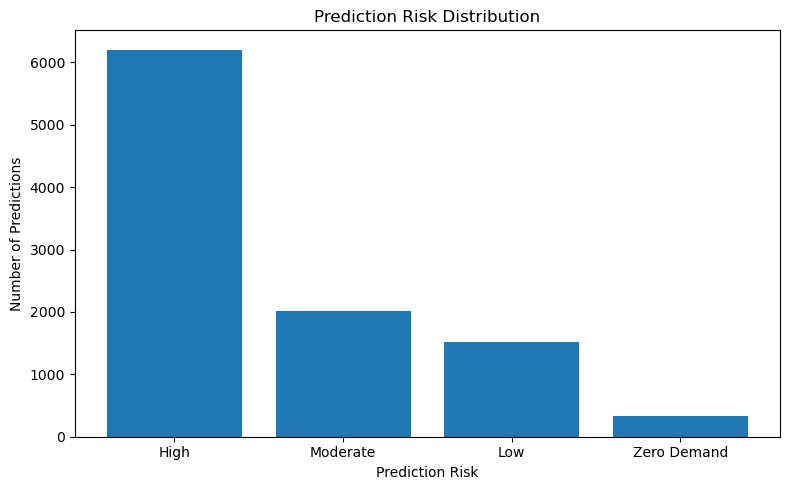

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["Prediction_Risk"].astype(str),
    risk_summary["Count"]
)

plt.xlabel("Prediction Risk")
plt.ylabel("Number of Predictions")
plt.title("Prediction Risk Distribution")

plt.tight_layout()
plt.show()

In [34]:
# Highest-risk predictions

high_risk = final_decision[
    final_decision["Prediction_Risk"] == "High"
].copy()

high_risk = high_risk.sort_values(
    "Absolute_Error",
    ascending=False
)

print("Number of high-risk predictions:", len(high_risk))

display(
    high_risk[
        [
            "StockCode",
            "MonthYear",
            "Next_Month_Quantity",
            "Predicted_Quantity",
            "Absolute_Error",
            "Relative_Error_Pct",
            "Suggested_Stock"
        ]
    ].head(20)
)

Number of high-risk predictions: 6204


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error,Relative_Error_Pct,Suggested_Stock
773,20971,2011-10,1389.0,7758.953156,6369.953156,458.599939,8535
3373,22086,2011-10,7898.0,3268.465711,4629.534289,58.616539,3596
8754,84879,2011-07,6545.0,2160.631928,4384.368072,66.988053,2377
8300,84077,2011-09,8084.0,3718.587406,4365.412594,54.000651,4091
772,20971,2011-09,4872.0,634.763165,4237.236835,86.971199,699
5263,22578,2011-10,5365.0,1876.107754,3488.892246,65.030610,2064
6809,22952,2011-08,3710.0,507.943911,3202.056089,86.308789,559
121,16014,2011-10,3606.0,415.205878,3190.794122,88.485694,457
3796,22197,2011-07,5421.0,2241.116024,3179.883976,58.658623,2466
380,20668,2011-10,4329.0,1448.436561,2880.563439,66.541082,1594


In [35]:
# Top high-risk predictions

high_risk = final_decision[
    final_decision["Prediction_Risk"] == "High"
].copy()

top_high_risk = high_risk.sort_values(
    "Relative_Error_Pct",
    ascending=False
).head(20)

print("Top 20 High-Risk Predictions")
print("=" * 80)

display(
    top_high_risk[
        [
            "StockCode",
            "MonthYear",
            "Next_Month_Quantity",
            "Predicted_Quantity",
            "Absolute_Error",
            "Relative_Error_Pct",
            "Suggested_Stock"
        ]
    ]
)

Top 20 High-Risk Predictions


,StockCode,MonthYear,Next_Month_Quantity,Predicted_Quantity,Absolute_Error,Relative_Error_Pct,Suggested_Stock
1191,21166,2011-07,1.0,653.375357,652.375357,65237.535691,719
5739,22687,2011-09,1.0,348.043606,347.043606,34704.360599,383
7185,23157,2011-11,1.0,306.421642,305.421642,30542.164182,338
899,21033,2011-08,1.0,240.123221,239.123221,23912.322127,265
34,15034,2011-11,2.0,477.219660,475.219660,23760.983015,525
457,20711,2011-11,1.0,222.255024,221.255024,22125.502438,245
979,21066,2011-11,1.0,204.267577,203.267577,20326.757714,225
8213,82600,2011-09,4.0,817.048936,813.048936,20326.223400,899
2660,21823,2011-10,3.0,498.215020,495.215020,16507.167338,549
2675,21830,2011-10,1.0,161.807124,160.807124,16080.712378,178


In [36]:
# Prediction risk summary

risk_summary = (
    final_decision
    .groupby("Prediction_Risk")
    .agg(
        Predictions=("StockCode", "count"),
        Avg_Absolute_Error=("Absolute_Error", "mean"),
        Avg_Relative_Error=("Relative_Error_Pct", "mean"),
        Avg_Actual_Demand=("Next_Month_Quantity", "mean"),
        Avg_Predicted_Demand=("Predicted_Quantity", "mean"),
        Avg_Suggested_Stock=("Suggested_Stock", "mean")
    )
    .reset_index()
)

print("Prediction Risk Summary")
print("=" * 80)

display(risk_summary)

Prediction Risk Summary


,Prediction_Risk,Predictions,Avg_Absolute_Error,Avg_Relative_Error,Avg_Actual_Demand,Avg_Predicted_Demand,Avg_Suggested_Stock
0,High,6204,127.180577,598.831308,120.224371,146.450266,161.612186
1,Low,1524,32.179347,9.957518,309.389764,303.110298,333.923885
2,Moderate,2022,119.474572,34.345404,343.100396,285.248276,314.270524
3,Zero Demand,333,45.082685,NaN,0.000000,45.082685,50.171171


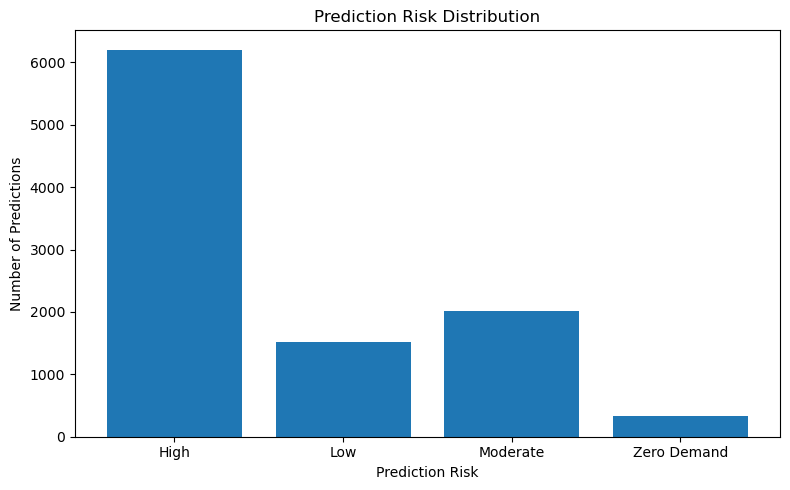

In [37]:
# Prediction Risk Distribution

plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["Prediction_Risk"],
    risk_summary["Predictions"]
)

plt.xlabel("Prediction Risk")
plt.ylabel("Number of Predictions")
plt.title("Prediction Risk Distribution")

plt.tight_layout()
plt.show()

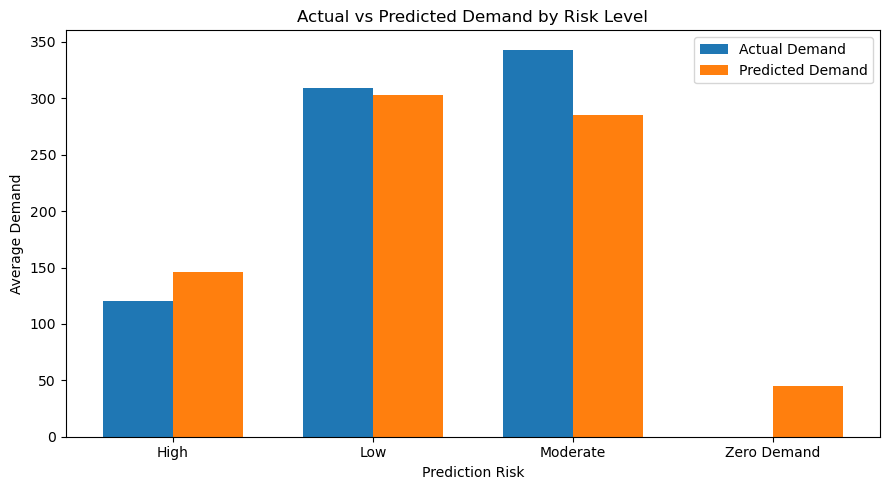

In [38]:
# Actual vs Predicted Demand by Risk Level

plt.figure(figsize=(9, 5))

x = np.arange(len(risk_summary))
width = 0.35

plt.bar(
    x - width / 2,
    risk_summary["Avg_Actual_Demand"],
    width,
    label="Actual Demand"
)

plt.bar(
    x + width / 2,
    risk_summary["Avg_Predicted_Demand"],
    width,
    label="Predicted Demand"
)

plt.xlabel("Prediction Risk")
plt.ylabel("Average Demand")
plt.title("Actual vs Predicted Demand by Risk Level")

plt.xticks(
    x,
    risk_summary["Prediction_Risk"]
)

plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Business Action Recommendations

business_actions = pd.DataFrame({
    "Prediction_Risk": [
        "High",
        "Moderate",
        "Low",
        "Zero Demand"
    ],
    "Business_Action": [
        "Review prediction manually and maintain cautious inventory planning",
        "Monitor demand and adjust stock based on recent trends",
        "Use predicted demand for normal inventory planning",
        "Avoid unnecessary stock and investigate whether the product is inactive"
    ]
})

display(business_actions)

,Prediction_Risk,Business_Action
0,High,Review prediction manually and maintain cautio...
1,Moderate,Monitor demand and adjust stock based on recen...
2,Low,Use predicted demand for normal inventory plan...
3,Zero Demand,Avoid unnecessary stock and investigate whethe...


In [40]:
# Overall Business Summary

total_predictions = len(final_decision)
high_risk_count = (final_decision["Prediction_Risk"] == "High").sum()
moderate_count = (final_decision["Prediction_Risk"] == "Moderate").sum()
low_count = (final_decision["Prediction_Risk"] == "Low").sum()
zero_demand_count = (final_decision["Prediction_Risk"] == "Zero Demand").sum()

print("=" * 60)
print("BUSINESS INSIGHTS SUMMARY")
print("=" * 60)

print(f"Total predictions        : {total_predictions}")
print(f"High-risk predictions    : {high_risk_count}")
print(f"Moderate-risk predictions: {moderate_count}")
print(f"Low-risk predictions     : {low_count}")
print(f"Zero-demand predictions  : {zero_demand_count}")

print("\nKey Business Use:")
print("- Demand predictions can support inventory planning.")
print("- Prediction risk helps identify uncertain forecasts.")
print("- Suggested stock provides a simple inventory planning reference.")
print("- High-risk predictions should be reviewed before major stock decisions.")

BUSINESS INSIGHTS SUMMARY
Total predictions        : 10083
High-risk predictions    : 6204
Moderate-risk predictions: 2022
Low-risk predictions     : 1524
Zero-demand predictions  : 333

Key Business Use:
- Demand predictions can support inventory planning.
- Prediction risk helps identify uncertain forecasts.
- Suggested stock provides a simple inventory planning reference.
- High-risk predictions should be reviewed before major stock decisions.


In [41]:
# Save business insights summary

business_actions.to_csv(
    "../data/predictions/business_action_recommendations.csv",
    index=False
)

risk_summary.to_csv(
    "../data/predictions/prediction_risk_summary.csv",
    index=False
)

print("Business insight files saved successfully.")

Business insight files saved successfully.
